## Forecasting example
In this example we aim to predict a future value of a time-series characterized by a trend and an offset. The observation equation is given by

$$
Y(t) = y_0 + r t + \epsilon(t)
$$

We will follow the steps from [Chapter 4.7](Forecasting).

### Step 0: Load data and plot
In the following code we plot the time series. From the plot, we can clearly identify a linear trend. The observations are taken annually starting from 1900 to 2000. Our aim is to estimate the value of the time series in the year 2001.

In [3]:
# Import necessary libraries

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

y0 = 100 # intercept
r = 2 # slope

# Parameters for the AR(1) process
sigma = 11          # Standard deviation of the noise
n = 101            # Length of the time series

# Initialize the process
np.random.seed(42)  # For reproducibility
noise_AR = np.zeros(n)
noise_AR[0] = np.random.normal(0, sigma)  # Initial value
t = np.arange(1900, 2001, 1)

# Generate the AR(1) process and noise series
noise = np.random.normal(0, sigma, n)  # Pre-generate noise for the second plot
phi = 0.8
for lag in range(1, n):
        noise_AR[lag] = phi * noise_AR[lag-1] + noise[lag]  # Use pre-generated noise

# Add intercept and linear trend
data = y0 + r*t + noise_AR


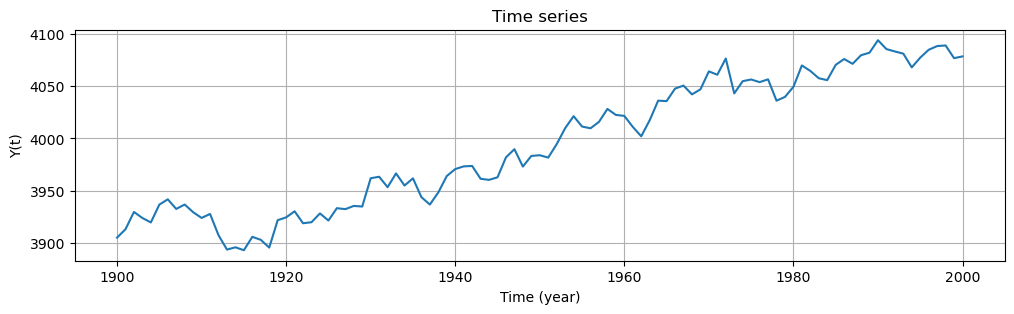

In [4]:
# Plot the time series
plt.figure(figsize=(12, 3))
plt.plot(t, data)
plt.title("Time series")
plt.xlabel("Time (year)")
plt.ylabel("Y(t)")
plt.grid(True)


### Step 1: Estimate the signal of interest

To estimate the linear trend and offset we can use the Least Squares estimator since we don't know the covariance matrix of the data. This is equivalent to fitting a linear model to the time series.

The observation equation is written as:

$$
Y(t) = y_0 + r t + o {u_k(t)} + \epsilon(t).
$$

Therefore, the linear functional model for the $101$ observables is expressed as:

$$
\mathbb{E}(\underset{\mathrm{Y}}{\underbrace{\begin{bmatrix} Y_1 \\ \vdots \\ Y_{101} \end{bmatrix}}} )= \underset{\mathrm{A}}{\underbrace{\begin{bmatrix} 1 & t_1 \\ \vdots & \vdots  \\  1 & t_{101} \end{bmatrix}}}\underset{\mathrm{x}}{\underbrace{\begin{bmatrix} y_0 \\ r  \end{bmatrix}}},
$$

and the least-squares solution of the unknown parameter vector $\mathrm{x}$ is obtained as:

$$
\mathrm{\hat{X}= (A^T A)^{-1} A^T \mathrm{Y}}.
$$

The time series without the linear trend and offset is simply the residuals:

$$
\mathrm{\hat{\epsilon}}= \mathrm{Y} - A\mathrm{\hat{Y}}.
$$

In the following code we estimate the linear trend and offset and remove them from the time series.

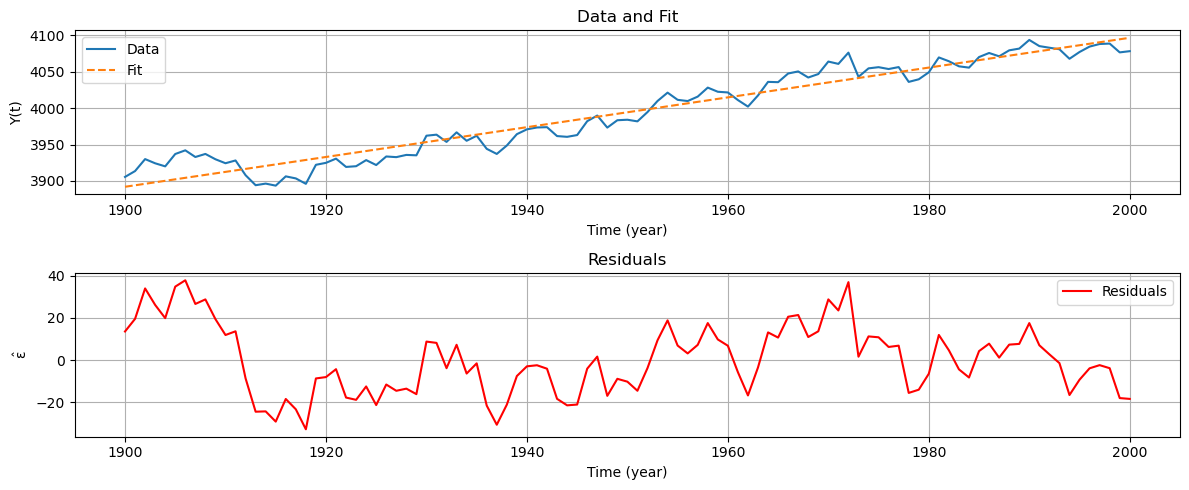

In [5]:
A = np.column_stack((np.ones_like(t), t))
xhat = np.linalg.solve(A.T @ A, A.T @ data)
yhat = A @ xhat
ehat = data - yhat

fig, axs = plt.subplots(2, 1, figsize=(12, 5))

# Plot data and fit
axs[0].plot(t, data, label='Data')
axs[0].plot(t, yhat, label='Fit', linestyle='--')
axs[0].set_xlabel('Time (year)')
axs[0].set_ylabel('Y(t)')
axs[0].set_title('Data and Fit')
axs[0].legend()
axs[0].grid()

# Plot residuals
axs[1].plot(t, ehat, label='Residuals', color='red')
axs[1].set_xlabel('Time (year)')
axs[1].set_ylabel('$\mathrm{\hat{\epsilon}}$')
axs[1].set_title('Residuals')
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()


In the above plots the blue line represents the time series $\mathrm{Y}$, the dashed orange line is the fitted line using the previously defined functional model $\hat{\mathrm{Y}} = \mathrm{A}\hat{\mathrm{x}}$, and the red line represents the residuals $\mathrm{\hat{\epsilon}}$. After detrending the time series, we can conclude that the residuals are stationary.

To be able to predict future values, we need to estimate the noise process. For this reason, in the next step we analyse the ACF of the residuals, to see if the noise process is uncorrelated

The next code, plots the residuals and its ACF:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


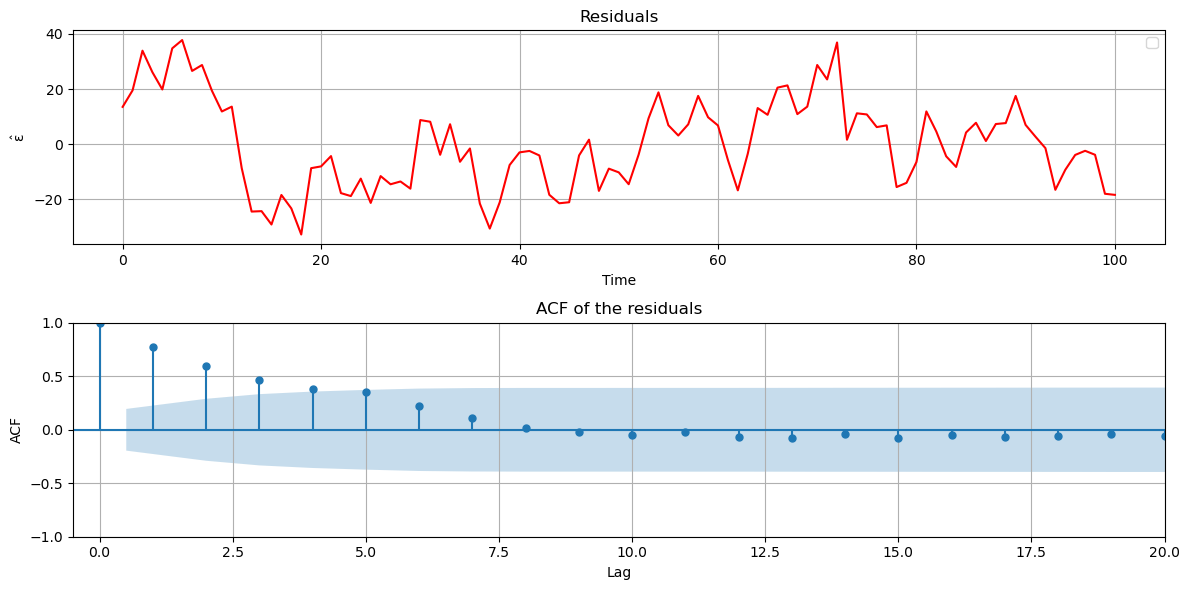

In [ ]:
# Create the 2x1 subplot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

# Plot residuals
ax1.plot(ehat,color='red')
ax1.set_ylabel('$\mathrm{\hat{\epsilon}}$')
ax1.set_title("Residuals")
ax1.set_xlabel("Time")
ax1.legend()
ax1.grid(True)

# Plot ACF
lags = 20
plot_acf(ehat, ax=ax2, lags=lags)
ax2.set_xlabel("Lag")
ax2.set_ylabel("ACF Value")
ax2.set_title("ACF of the residuals")
ax2.set_xlim(-0.5, lags)
ax2.set_xlabel("Lag")
ax2.set_ylabel("ACF")
ax2.grid(True)

# Display the plot
plt.tight_layout()
plt.show()

From the ACF of the residuals, we observe that they are time-correlated, with notably high values at the second lag and beyond. In the next step we model the residuals using the AR(1) model, and estimate the coefficient $\phi$.

### Step 2: Model the noise using the AR(1) model
To model the noise, we use the stationary time series $S_t = \hat{\epsilon}$, where $\hat{\epsilon}$ are the residuals obtained after detrending the time series.

$$
S_{t-1} = \phi S_{t-1} + \epsilon(t)
$$

$$
\underset{S_{t-1}}{\underbrace{\begin{bmatrix} S_2 \\ \vdots \\ S_{101} \end{bmatrix}}} = \underset{S_{t-1}}{\underbrace{\begin{bmatrix} S_1 \\ \vdots \\ S_{100} \end{bmatrix}}} \phi,
$$

and the least-squares solution of the unknown parameter $\phi$ is obtained as:
$$
\hat{\phi}= (S_{t-1}^T S_{t-1})^{-1} S_{t-1}^T S_{t-1}.
$$

### Step 2: Model the noise using the AR(1) model
To model the noise, we use the stationary time series $S_t = \hat{\epsilon}$, where $\hat{\epsilon}$ are the residuals obtained after detrending the time series.

$$
S_{t-1} = \phi S_{t-1} + \epsilon(t)
$$

$$
\underset{S_{t-1}}{\underbrace{\begin{bmatrix} S_2 \\ \vdots \\ S_{101} \end{bmatrix}}} = \underset{S_{t-1}}{\underbrace{\begin{bmatrix} S_1 \\ \vdots \\ S_{100} \end{bmatrix}}} \phi,
$$

and the least-squares solution of the unknown parameter $\phi$ is obtained as:
$$
\hat{\phi}= (S_{t-1}^T S_{t-1})^{-1} S_{t-1}^T S_{t-1}.
$$

100
100
AR(1) Coefficient:
Phi_1 =  0.787


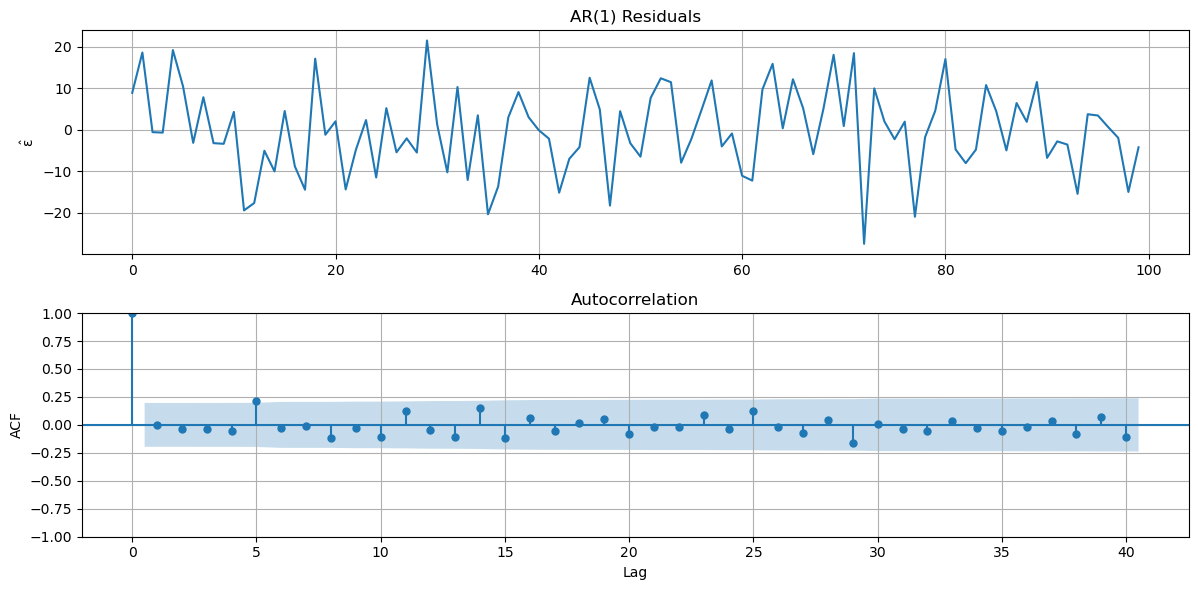

In [18]:
y = ehat[1:]
s1 = ehat[0:-1]

print(len(y))
print(len(s1))

# AR(1) model
X1 = np.column_stack((s1)).T
phi_ar1 = np.linalg.inv(X1.T @ X1) @ (X1.T @ y)
e1 = y - X1 @ phi_ar1

# Print AR(1) residuals
fig, ax = plt.subplots(2,1,figsize=(12, 6))
ax[0].plot(e1)
ax[0].set_title('AR(1) Residuals')
ax[0].set_ylabel('$\mathrm{\hat{\epsilon}}$')
ax[0].grid(True)

# Print ACF
plot_acf(e1, lags=40, ax=ax[1])
ax[1].set_xlabel("Lag")
ax[1].set_ylabel("ACF")
ax[1].grid(True)

fig.tight_layout()

# print the AR(1) coefficient
print('AR(1) Coefficient:')
print('Phi_1 = ', round(phi_ar1[0], 4))

After fitting the AR(1) model, we observe little to no correlation between lagged observations.

### Step 3: Predict the signal-of-interest for year 2001
Once we have characterized the signal and the noise


$$
\mathrm{\hat{Y}_{2001}}=  \underset{A_p}{\underbrace{\begin{bmatrix} 1 & 2001 \end{bmatrix}}} \underset{\hat{\mathrm{X}}}{\underbrace{\begin{bmatrix} \hat{y}_0 \\ \hat{r}  \end{bmatrix}}}.
$$

In [23]:
Ap = np.column_stack(([1], [2001]))
Y_signal =  Ap @ xhat

print('Y_signal = ', Y_signal)


Y_signal =  [4098.68613485]


### Step 4: Predict the noise for year 2001
a

In [ ]:
Ap = np.column_stack(([1], [2001]))
Y_signal =  Ap @ xhat

print('Y_signal = ', Y_signal)

### Step 5: Predict the time series for year 2001
Finally, the time series for year 2001 is predicted using the predicted signal-of-interest ($\hat{Y}_{signal} = A_p \hat{X}$ in Step 3), and the predicted noise ($\hat{\epsilon}_p$ in Step 4):

$$
\mathrm{\hat{Y}_{2001}}=  \underset{A_p}{\underbrace{\begin{bmatrix} 1 & 2001 \end{bmatrix}}} \underset{\hat{\mathrm{X}}}{\underbrace{\begin{bmatrix} \hat{y}_0 \\ \hat{r}  \end{bmatrix}}} + \hat{\epsilon}_p.
$$

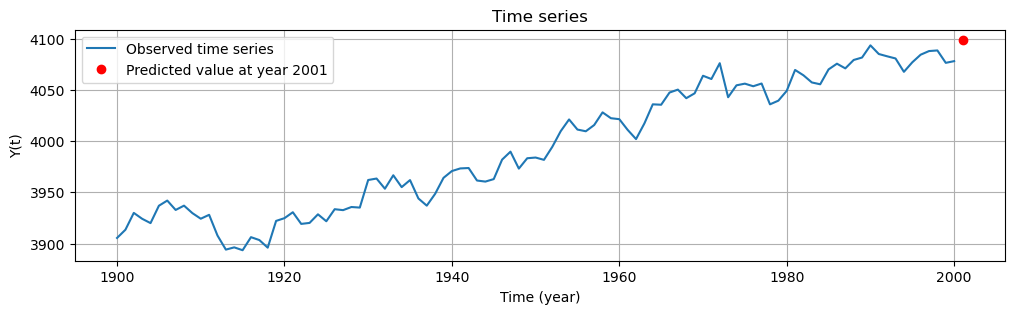

In [30]:
# Plot the time series
plt.figure(figsize=(12, 3))
plt.plot(t, data, label="Observed time series")
plt.plot(2001, Y_signal, 'ro', label="Predicted value at year 2001")  # red point  # red circle marker


plt.title("Time series")
plt.xlabel("Time (year)")
plt.ylabel("Y(t)")
plt.legend()
plt.grid(True)
